In [1]:
import pandas as pd
import plotly.express as px
import polars as pl

# College

In [2]:
lazy_df = pl.scan_csv(
    "../../datasets/College.csv",
    # infer_schema_length=10000 # Workaround if inferring fails in Polars
)

In [3]:
q = lazy_df.select(pl.col("*"))
df = q.collect()
df.describe()

statistic,,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""777""","""777""",777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
"""std""",null,null,3870.201484,2451.113971,929.17619,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.10536,677.071454,16.328155,14.722359,3.958349,12.391801,5221.76844,17.17771
"""min""","""Abilene Christian University""","""No""",81.0,72.0,35.0,1.0,9.0,139.0,1.0,2340.0,1780.0,96.0,250.0,8.0,24.0,2.5,0.0,3186.0,10.0
"""25%""",null,null,776.0,604.0,242.0,15.0,41.0,992.0,95.0,7320.0,3597.0,470.0,850.0,62.0,71.0,11.5,13.0,6751.0,53.0
"""50%""",null,null,1558.0,1110.0,434.0,23.0,54.0,1707.0,353.0,9990.0,4200.0,500.0,1200.0,75.0,82.0,13.6,21.0,8377.0,65.0
"""75%""",null,null,3624.0,2424.0,902.0,35.0,69.0,4005.0,967.0,12925.0,5050.0,600.0,1700.0,85.0,92.0,16.5,31.0,10830.0,78.0
"""max""","""York College of Pennsylvania""","""Yes""",48094.0,26330.0,6392.0,96.0,100.0,31643.0,21836.0,21700.0,8124.0,2340.0,6800.0,103.0,100.0,39.8,64.0,56233.0,118.0


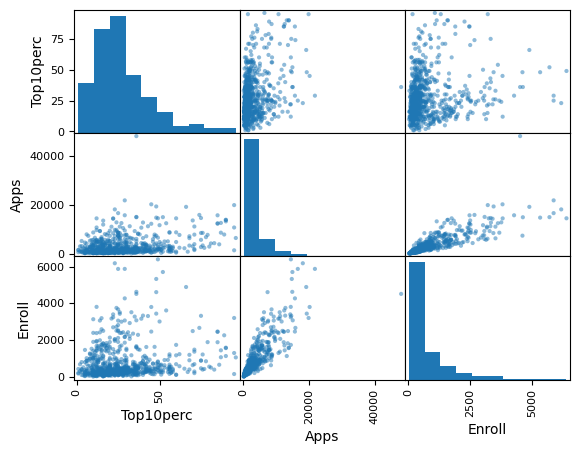

In [4]:
q = lazy_df.select(pl.col("Top10perc"), pl.col("Apps"), pl.col("Enroll"))
scatter_matrix_top10_apps_enroll = q.collect()
pd.plotting.scatter_matrix(scatter_matrix_top10_apps_enroll.to_pandas());

In [6]:
q = lazy_df.select(
    pl.col("Outstate"),
    pl.col("Private"),
)
df = q.collect().to_pandas()
fig = px.box(y=df["Outstate"], x=df["Private"], width=800, height=600)
fig.update_layout(
    margin={"l": 20, "r": 20, "t": 20, "b": 20},
    paper_bgcolor="LightSteelBlue",
)

In [10]:
q = lazy_df.with_columns((pl.col("Top10perc") > 50).alias("elite")).select(
    pl.col("Outstate"),
    pl.col("elite"),
)
df = q.collect().to_pandas()

fig = px.box(y=df["Outstate"], x=df["elite"], width=800, height=600)
fig.update_layout(
    margin={"l": 20, "r": 20, "t": 20, "b": 20},
    paper_bgcolor="LightSteelBlue",
)

# Cars

In [2]:
schema = {
    "mpg": pl.Float64,
    "cylinders": pl.Int64,
    "displacement": pl.Float64,
    "horsepower": pl.Int64,
    "weight": pl.Int64,
    "acceleration": pl.Float64,
    "year": pl.Int64,
    "origin": pl.Int64,
    "name": pl.String,
}

In [3]:
lazy_df = pl.scan_csv(
    "../../datasets/Auto.csv",
    null_values="?",
    schema_overrides=schema,  # Can also manually specify
).drop_nulls()

In [4]:
q = lazy_df.select(pl.col("*"))
df = q.collect()
df.describe()

statistic,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
str,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",392.0,392.0,392.0,392.0,392.0,392.0,392.0,392.0,"""392"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",23.445918,5.471939,194.41199,104.469388,2977.584184,15.541327,75.979592,1.576531,null
"""std""",7.805007,1.705783,104.644004,38.49116,849.40256,2.758864,3.683737,0.805518,null
"""min""",9.0,3.0,68.0,46.0,1613.0,8.0,70.0,1.0,"""amc ambassador brougham"""
"""25%""",17.0,4.0,105.0,75.0,2226.0,13.8,73.0,1.0,null
"""50%""",23.0,4.0,151.0,94.0,2807.0,15.5,76.0,1.0,null
"""75%""",29.0,8.0,267.0,125.0,3613.0,17.0,79.0,2.0,null
"""max""",46.6,8.0,455.0,230.0,5140.0,24.8,82.0,3.0,"""vw rabbit custom"""


In [6]:
q = lazy_df.select(pl.col("*")).with_row_index()
df = q.collect()
df = df[:10].vstack(df[85:])
df.describe()

statistic,index,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0,"""317"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",230.634069,24.374763,5.381703,187.880126,101.003155,2938.85489,15.704101,77.123028,1.599369,null
"""std""",96.444441,7.872565,1.658135,100.169973,36.003208,811.640668,2.719913,3.127158,0.819308,null
"""min""",0.0,11.0,3.0,68.0,46.0,1649.0,8.5,70.0,1.0,"""amc ambassador brougham"""
"""25%""",154.0,18.0,4.0,101.0,75.0,2215.0,14.0,75.0,1.0,null
"""50%""",233.0,23.9,4.0,146.0,90.0,2795.0,15.5,77.0,1.0,null
"""75%""",312.0,30.5,6.0,250.0,115.0,3520.0,17.3,80.0,2.0,null
"""max""",391.0,46.6,8.0,455.0,230.0,4997.0,24.8,82.0,3.0,"""vw rabbit custom"""


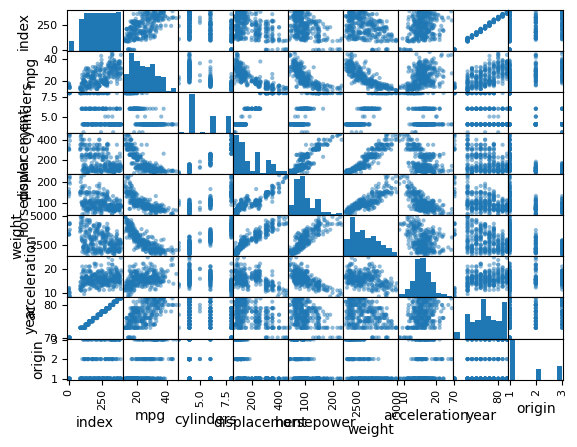

In [8]:
pd.plotting.scatter_matrix(df.to_pandas());

# Boston

In [9]:
lazy_df = pl.scan_csv(
    "../../datasets/Boston.csv",
)

In [12]:
q = lazy_df.select(pl.col("*"))
df = q.collect()
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
…,…,…,…,…,…,…,…,…,…,…,…,…,…
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.12,76.7,2.2875,1,273,21.0,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9


In [13]:
df.describe()

statistic,,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",253.5,3.613524,11.363636,11.136779,0.06917,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
"""std""",146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.10571,8.707259,168.537116,2.164946,7.141062,9.197104
"""min""",1.0,0.00632,0.0,0.46,0.0,0.385,3.561,2.9,1.1296,1.0,187.0,12.6,1.73,5.0
"""25%""",127.0,0.08199,0.0,5.19,0.0,0.449,5.885,45.0,2.1,4.0,279.0,17.4,6.93,17.0
"""50%""",254.0,0.25915,0.0,9.69,0.0,0.538,6.209,77.7,3.2157,5.0,330.0,19.1,11.38,21.2
"""75%""",380.0,3.67822,12.5,18.1,0.0,0.624,6.625,94.1,5.2119,24.0,666.0,20.2,16.96,25.0
"""max""",506.0,88.9762,100.0,27.74,1.0,0.871,8.78,100.0,12.1265,24.0,711.0,22.0,37.97,50.0


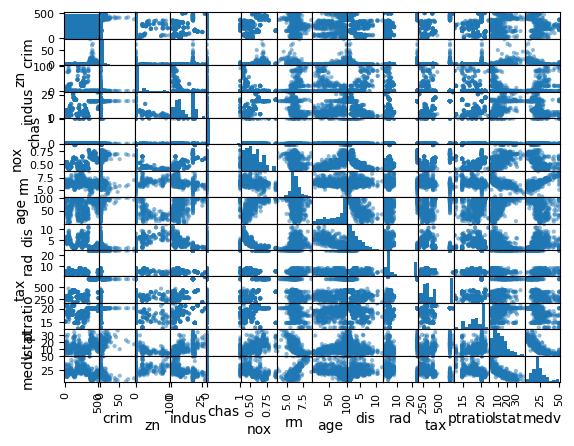

In [11]:
pd.plotting.scatter_matrix(df.to_pandas());